In [344]:
import json
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from collections import defaultdict

# file_list = ['results/done/4_2_2/baseline.json',
#              'results/done/4_2_2/corelation.json',
#              'results/done/4_2_2/mcq.json',
#              'results/done/4_2_2/mcq_co.json',
#              'results/done/4_2_2/rank.json',
#              'results/done/4_2_2/rank_co.json']

# file_list = ['results/done/4_4_2/baseline_49.json',
#              'results/done/4_4_2/correlation_49.json',
#              'results/done/4_4_2/mcq_llm_49.json',
#              'results/done/4_4_2/mcq_co_llm_49.json',
#              'results/done/4_4_2/rank_llm_49.json',
#              'results/done/4_4_2/rank_co_llm_49.json']

# Use this for plots
file_list = ['results/done/6_2_2/baseline.json',
             'results/done/6_2_2/correlation.json',
             'results/done/6_2_2/mcq.json',
             'results/done/6_2_2/mcq_co.json',
             'results/done/6_2_2/rank.json',
             'results/done/6_2_2/rank_co.json']

# file_list = ['results/done/6_4_2/baseline.json',
#              'results/done/6_4_2/correlation.json',
#              'results/done/6_4_2/mcq.json',
#              'results/done/6_4_2/mcq_co.json',
#              'results/done/6_4_2/rank.json',
#              'results/done/6_4_2/rank_co.json']

# file_list = ['results/done/8_2_2/baseline.json',
#              'results/done/8_2_2/correlation.json',
#              'results/done/8_2_2/mcq.json',
#              'results/done/8_2_2/mcq_co.json',
#              'results/done/8_2_2/rank.json',
#              'results/done/8_2_2/rank_co.json']

# file_list = ['results/done/8_4_2/baseline.json',
#              'results/done/8_4_2/correlation.json',
#              'results/done/8_4_2/mcq.json',
#              'results/done/8_4_2/mcq_co.json',
#              'results/done/8_4_2/rank.json',
#              'results/done/8_4_2/rank_co.json']

experiment_names = ['Baseline',
                    'Co-Model',
                    'MCQA',
                    'MCQA with Co-Model',
                    'Rank',
                    'Rank with Co-Model']

In [345]:
with open(file_list[0], 'r') as f:
    baseline = json.load(f)
with open(file_list[1], 'r') as f:
    correlation = json.load(f)
with open(file_list[2], 'r') as f:
    mcq = json.load(f)
with open(file_list[3], 'r') as f:
    mcq_co = json.load(f)
with open(file_list[4], 'r') as f:
    rank = json.load(f)
with open(file_list[5], 'r') as f:
    rank_co = json.load(f)

[1771.6  751.3 1230.9  629.4 1145.7  530.4]
[810.8 340.6 760.8 414.3 689.3 310.7]


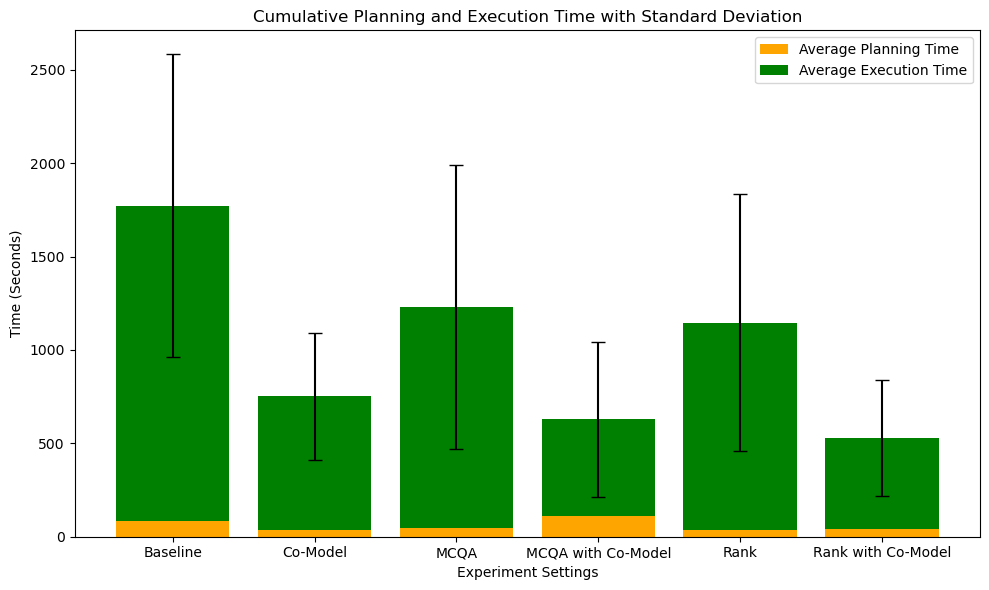

In [346]:
exp_names = []
avg_execution_time = []
avg_planning_time = []
total_time_std = []
for exp_name, filename in zip(experiment_names, file_list):
    exp_names.append(exp_name)
    with open(filename, 'r') as f:
        data = json.load(f)
    # Extract the average execution time
    execution_time = []
    for exp in data:
        if exp.isdigit():
            if data[exp]["result"] == "Success":
                execution_time.append(data[exp]["total_base_distance"] * 4)
    avg_execution_time.append(np.mean(execution_time))
    # Extract the average planning time
    planning_time = []
    for exp in data:
        if exp.isdigit():
            if data[exp]["result"] == "Success":
                planning_time.append(data[exp]["total_planning_time"])
    avg_planning_time.append(np.mean(planning_time))
    # Extract the total time
    total_time = []
    for exp in data:
        if exp.isdigit():
            if data[exp]["result"] == "Success":
                total_time.append(data[exp]["total_base_distance"] * 4 + data[exp]["total_planning_time"])
    total_time_std.append(np.std(total_time))

# Compute cumulative values for stacking
bottom_execution = np.array(avg_planning_time)
print(np.round(np.array(avg_planning_time) + np.array(avg_execution_time), 1))
print(np.round(total_time_std, 1))
# Create the bar chart
x = np.arange(len(exp_names))

plt.figure(figsize=(10, 6))
plt.bar(x, avg_planning_time, label='Average Planning Time', color='orange')
plt.bar(x, avg_execution_time, bottom=bottom_execution, yerr=total_time_std, capsize=5, label='Average Execution Time', color='green')

# Add labels and legend
plt.xlabel('Experiment Settings')
plt.ylabel('Time (Seconds)')
plt.title('Cumulative Planning and Execution Time with Standard Deviation')
plt.xticks(x, exp_names)
plt.legend()

# Show the plot
plt.tight_layout()
plt.show()

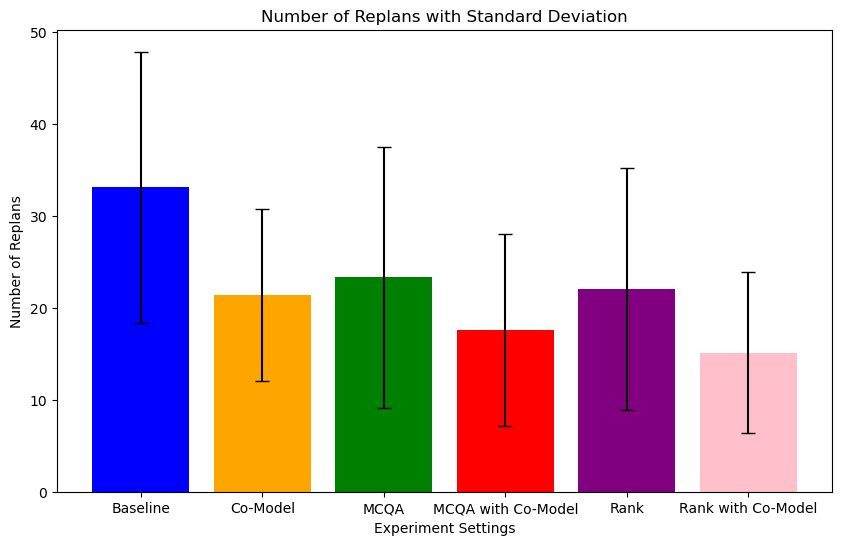

In [347]:
data_dict = defaultdict(list)
for exp_name, filename in zip(experiment_names, file_list):
    with open(filename, 'r') as f:
        data = json.load(f)
    # Extract the experiment name
    data_dict["Experiment"].append(exp_name)
    # Extract the average steps
    total_steps = 0
    for exp in data:
        if exp.isdigit():
            if data[exp]["result"] == "Success":
                total_steps += data[exp]["steps"]
    data_dict["Average Number of Replans"].append(total_steps / len(data))
    # Collect all step values
    steps_list = []
    for key, value in data.items():
        if key.isdigit():
            steps_list.append(value['steps'])
    data_dict["Steps Std Dev"].append(np.std(steps_list))

# Create DataFrame
df = pd.DataFrame(data_dict)

# Plotting the bar chart with more distinct and visible colors
distinct_colors = ['blue', 'orange', 'green', 'red', 'purple', 'pink']

plt.figure(figsize=(10, 6))
plt.bar(df["Experiment"], df["Average Number of Replans"], yerr=df["Steps Std Dev"], capsize=5, color=distinct_colors)
plt.title("Number of Replans with Standard Deviation")
plt.xlabel("Experiment Settings")
plt.ylabel("Number of Replans")

# Display the updated plot
plt.show()

In [348]:
np.round(df, 1)

,Experiment,Average Number of Replans,Steps Std Dev
0,Baseline,33.1,14.8
1,Co-Model,21.4,9.3
2,MCQA,23.3,14.2
3,MCQA with Co-Model,17.6,10.5
4,Rank,22.1,13.2
5,Rank with Co-Model,15.1,8.7


In [349]:
import scipy.stats as stats

def gen_ci_steps(res, best):
    diffs = []
    for (res_key, res_val), (best_key, best_val) in zip(res.items(), best.items()):
        if res_key.isdigit() and best_key.isdigit():
            if res_val['result'] == "Success" and best_val['result'] == "Success":
                diffs.append(int(res_val['steps']) - int(best_val['steps']))
    mean = np.mean(diffs)
    # 95% confidence interval
    confidence_level = 0.95
    ci = stats.t.interval(confidence_level, 
                        len(diffs)-1, 
                        loc=np.mean(diffs), 
                        scale=stats.sem(diffs))
    return mean, ci

def gen_ci_time(res, best):
    diffs = []
    for (res_key, res_val), (best_key, best_val) in zip(res.items(), best.items()):
        if res_key.isdigit() and best_key.isdigit():
            if res_val['result'] == "Success" and best_val['result'] == "Success":
                res_val = res_val['total_base_distance'] * 4 + res_val['total_planning_time']
                best_val = best_val['total_base_distance'] * 4 + best_val['total_planning_time']
                diffs.append(res_val - best_val)
    mean = np.mean(diffs)
    # 95% confidence interval
    confidence_level = 0.95
    ci = stats.t.interval(confidence_level, 
                        len(diffs)-1, 
                        loc=np.mean(diffs), 
                        scale=stats.sem(diffs))
    return mean, ci

In [350]:
baseline_mean, baseline_ci = gen_ci_steps(baseline, rank_co)
co_mean_baseline, co_ci_baseline = gen_ci_steps(correlation, rank_co)
mcq_mean_baseline, mcq_ci_baseline = gen_ci_steps(mcq, rank_co)
mcq_co_mean_baseline, mcq_co_ci_baseline = gen_ci_steps(mcq_co, rank_co)
rank_mean_baseline, rank_ci_baseline = gen_ci_steps(rank, rank_co)

# baseline_mean, baseline_ci = gen_ci_steps(baseline, mcq_co)
# co_mean_baseline, co_ci_baseline = gen_ci_steps(correlation, mcq_co)
# mcq_mean_baseline, mcq_ci_baseline = gen_ci_steps(mcq, mcq_co)
# rank_mean_baseline, rank_ci_baseline = gen_ci_steps(rank, mcq_co)
# rank_co_mean_baseline, rank_co_ci_baseline = gen_ci_steps(rank_co, mcq_co)

[18.   6.3  8.2  2.4  6.9]
[4.9 2.9 4.2 2.8 4. ]
[4.9 2.9 4.2 2.8 4. ]


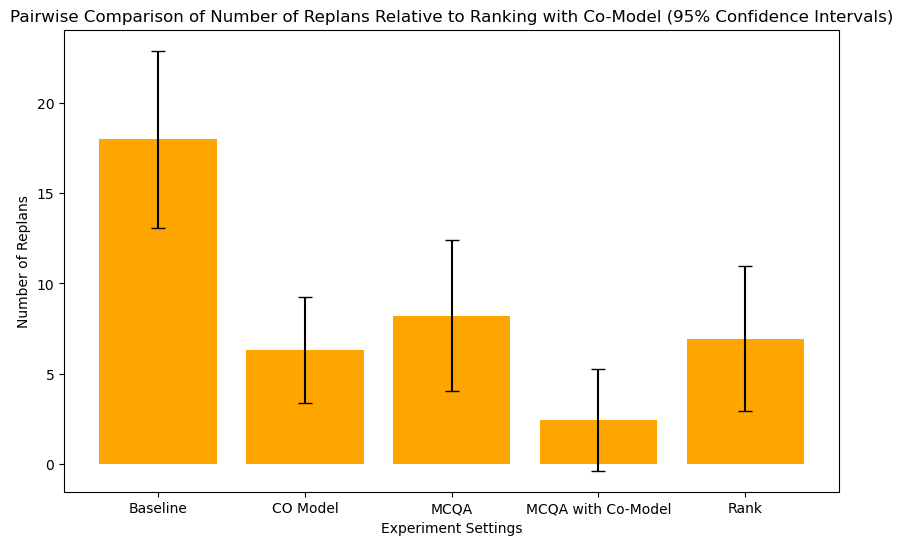

In [352]:
# Labels and means
labels = ['Baseline', 'CO Model', 'MCQA', 'MCQA with Co-Model', 'Rank']
means = [baseline_mean, co_mean_baseline, mcq_mean_baseline, mcq_co_mean_baseline, rank_mean_baseline]
cis_lower = [baseline_mean - baseline_ci[0], co_mean_baseline - co_ci_baseline[0], mcq_mean_baseline - mcq_ci_baseline[0], mcq_co_mean_baseline - mcq_co_ci_baseline[0], rank_mean_baseline - rank_ci_baseline[0]]
cis_upper = [baseline_ci[1] - baseline_mean, co_ci_baseline[1] - co_mean_baseline, mcq_ci_baseline[1] - mcq_mean_baseline, mcq_co_ci_baseline[1] - mcq_co_mean_baseline, rank_ci_baseline[1] - rank_mean_baseline]

# labels = ['Baseline', 'CO Model', 'MCQ', 'Rank', 'Rank with Co-Model']
# means = [baseline_mean, co_mean_baseline, mcq_mean_baseline, rank_mean_baseline, rank_co_mean_baseline]
# cis_lower = [baseline_mean - baseline_ci[0], co_mean_baseline - co_ci_baseline[0], mcq_mean_baseline - mcq_ci_baseline[0], rank_mean_baseline - rank_ci_baseline[0], rank_co_mean_baseline - rank_co_ci_baseline[0]]
# cis_upper = [baseline_ci[1] - baseline_mean, co_ci_baseline[1] - co_mean_baseline, mcq_ci_baseline[1] - mcq_mean_baseline, rank_ci_baseline[1] - rank_mean_baseline, rank_co_ci_baseline[1] - rank_co_mean_baseline]

print(np.round(means, 1))
print(np.round(cis_lower, 1))
print(np.round(cis_upper, 1))

# Bar plot with confidence intervals
fig, ax = plt.subplots(figsize=(10, 6))
ax.bar(labels, means, yerr=[cis_lower, cis_upper], capsize=5, color='orange')

# Labeling
ax.set_xlabel('Experiment Settings')
ax.set_ylabel('Number of Replans')
ax.set_title('Pairwise Comparison of Number of Replans Relative to Ranking with Co-Model (95% Confidence Intervals)')
plt.show()

In [115]:
# baseline = np.array([1021, 1624, 1771, 2986, 2367, 4782])
# best = np.array([435, 567, 530, 980, 746, 1205])
baseline = np.array([19, 35, 33, 51, 38, 70])
best = np.array([12, 21, 15, 26, 19, 35])
diff = baseline - best
print(diff)

[ 7 14 18 25 19 35]


In [116]:
np.mean(diff/baseline)

0.46734527941958276

In [156]:
265/365

0.726027397260274

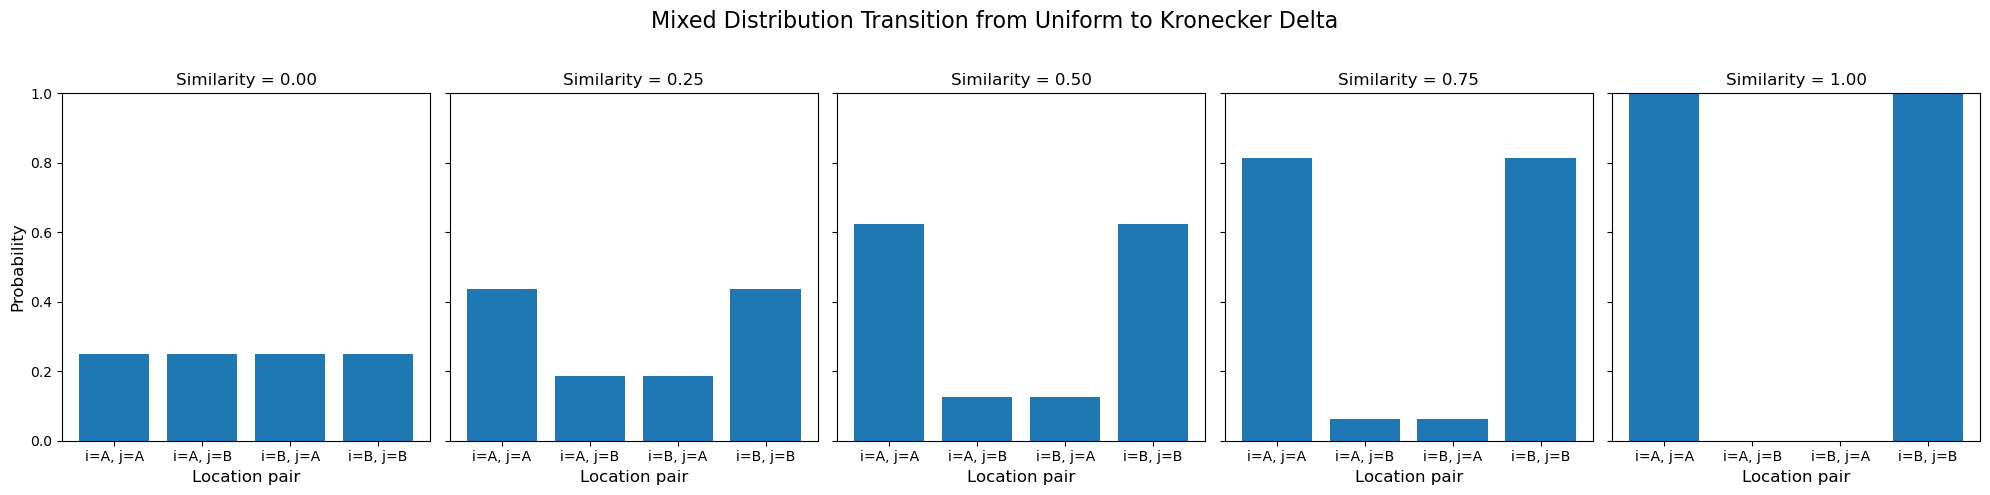

In [133]:
import matplotlib.pyplot as plt
import numpy as np


def uniform_dist(a, b):
    return 0.25

def kronecker_dist(a, b):
    if a == b:
        return 1
    return 0

i = ['A', 'B']
j = ['A', 'B']
similarities = [0.00, 0.25, 0.50, 0.75, 1.00]

probabilities = []
for sim in similarities:
    prob_set = []
    for loc_i in i:
        for loc_j in j:
            prob = sim * kronecker_dist(loc_i, loc_j) + (1- sim) * uniform_dist(loc_i, loc_j)
            prob_set.append(prob)
    probabilities.append(prob_set)
  

location_pairs = ['i=A, j=A', 'i=A, j=B', 'i=B, j=A', 'i=B, j=B']

# Plotting
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
fig.suptitle("Mixed Distribution Transition from Uniform to Kronecker Delta", fontsize=16)

for i, ax in enumerate(axes):
    ax.bar(location_pairs, probabilities[i])
    ax.set_title(f"Similarity = {similarities[i]:.2f}")
    ax.set_xlabel("Location pair", fontsize=12)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Probability", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the main title
plt.show()

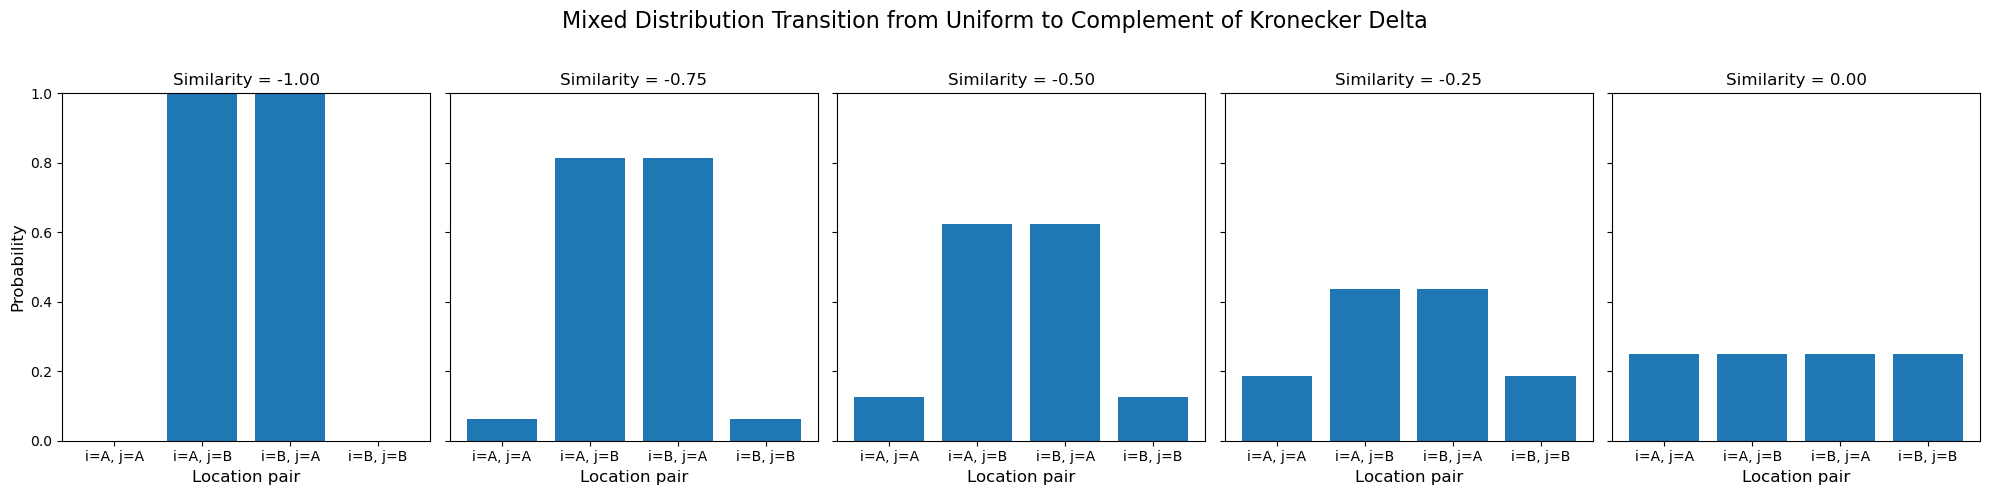

In [134]:
import matplotlib.pyplot as plt
import numpy as np


def uniform_dist(a, b):
    return 0.25

def inv_kronecker_dist(a, b):
    if a == b:
        return 0
    return 1

i = ['A', 'B']
j = ['A', 'B']
similarities = [-1.00, -0.75, -0.50, -0.25, 0.00]

probabilities = []
for sim in similarities:
    prob_set = []
    for loc_i in i:
        for loc_j in j:
            prob = abs(sim) * inv_kronecker_dist(loc_i, loc_j) + (1+sim) * uniform_dist(loc_i, loc_j)
            prob_set.append(prob)
    probabilities.append(prob_set)
  

location_pairs = ['i=A, j=A', 'i=A, j=B', 'i=B, j=A', 'i=B, j=B']

# Plotting
fig, axes = plt.subplots(1, 5, figsize=(20, 5), sharey=True)
fig.suptitle("Mixed Distribution Transition from Uniform to Complement of Kronecker Delta", fontsize=16)

for i, ax in enumerate(axes):
    ax.bar(location_pairs, probabilities[i])
    ax.set_title(f"Similarity = {similarities[i]:.2f}")
    ax.set_xlabel("Location pair", fontsize=12)
    ax.set_ylim(0, 1)

axes[0].set_ylabel("Probability", fontsize=12)

plt.tight_layout(rect=[0, 0, 1, 0.96])  # Adjust layout to make room for the main title
plt.show()